# 🌸 Data Visualization using Seaborn — Iris Dataset
---
**Author:** Data Science Lab  
**Dataset:** Iris Flower Dataset (150 samples · 3 species · 4 features)  
**Library:** Seaborn (built on Matplotlib)

> **Seaborn** is a Python data-visualization library that provides a high-level interface for drawing attractive and informative statistical graphics. It builds on top of Matplotlib and integrates closely with Pandas DataFrames.

---


* ##  Importing Libraries

We import visualization libraries (**Seaborn**, **Matplotlib**), data-processing libraries (**Pandas**, **NumPy**), and Scikit-learn modules for model building, evaluation, and preprocessing.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from pathlib import Path

In [2]:
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13,
                     "axes.labelsize": 11, "legend.fontsize": 10})

---
* ##  Loading & Preparing the Dataset

We load the Iris CSV, drop the index column, rename features for cleanliness, and strip the `Iris-` prefix from species labels. We then encode the target column into integers (required by most sklearn models).

 Species | Description |
|---|---|
| *Iris-setosa* | Easily separable — small petals |
| *Iris-versicolor* | Overlaps slightly with virginica |
| *Iris-virginica* | Largest petals among the three |

Each sample records **four measurements** (in centimetres):
- Sepal Length & Sepal Width
- Petal Length & Petal Width

In [3]:
BASE_DIR = Path.cwd().parent
file_path = BASE_DIR / 'data' / 'Iris.csv'

df = pd.read_csv(file_path)
df.drop(columns=['Id'], inplace=True)
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df['species'] = df['species'].str.replace('Iris-', '', regex=False)


le = LabelEncoder()
df['species_enc'] = le.fit_transform(df['species'])   
class_names = le.classes_

print(f"Shape          : {df.shape}")
print(f"Species labels : {class_names.tolist()} → {[0,1,2]}")
df.head(8)

Shape          : (150, 6)
Species labels : ['setosa', 'versicolor', 'virginica'] → [0, 1, 2]


,sepal_length,sepal_width,petal_length,petal_width,species,species_enc
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0
5,5.4,3.9,1.7,0.4,setosa,0
6,4.6,3.4,1.4,0.3,setosa,0
7,5.0,3.4,1.5,0.2,setosa,0


---
* ## Exploratory Data Analysis (EDA)

Before building models, it is essential to understand the data — its distributions, feature relationships, and class balance.

In [4]:
print("── Data Types ──────────────────────────────")
print(df.dtypes)
print()

print("── Class Distribution ──────────────────────")
print(df['species'].value_counts())

── Data Types ──────────────────────────────
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
species_enc       int32
dtype: object

── Class Distribution ──────────────────────
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


The dataset is **perfectly balanced** — exactly 50 samples per species. All four measurement columns are continuous `float64` values, while `species` is a categorical string column.

In [5]:
print("── Descriptive Statistics ──────────────────────────")
df.describe().round(2)

── Descriptive Statistics ──────────────────────────


,sepal_length,sepal_width,petal_length,petal_width,species_enc
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20,1.00
std,0.83,0.43,1.76,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


**Key observations from the statistics:**
- Petal features have far higher variance (std ≈ 1.76 for petal_length) than sepal features.
- Petal width ranges from 0.1 cm (setosa) to 2.5 cm (virginica) — a huge spread.
- Sepal width is the most tightly distributed feature overall.

### Per-Species Summary Table

A grouped aggregation reveals how much each species differs across all four measurements.

In [6]:
summary = (df.groupby('species')[['sepal_length','sepal_width','petal_length','petal_width']]
             .agg(['mean','std','min','max']).round(2))
summary.columns = ['_'.join(c) for c in summary.columns]
summary.T

species,setosa,versicolor,virginica
sepal_length_mean,5.01,5.94,6.59
sepal_length_std,0.35,0.52,0.64
sepal_length_min,4.30,4.90,4.90
sepal_length_max,5.80,7.00,7.90
sepal_width_mean,3.42,2.77,2.97
sepal_width_std,0.38,0.31,0.32
sepal_width_min,2.30,2.00,2.20
sepal_width_max,4.40,3.40,3.80
petal_length_mean,1.46,4.26,5.55
petal_length_std,0.17,0.47,0.55


**Interpretation:**
- **Setosa** has the smallest petal dimensions but relatively wide sepals.
- **Virginica** has the largest sepal and petal measurements overall.
- **Versicolor** is the intermediate species across all features.

This separation is crucial for building classification models on this data.


### 1. Line Plots

A **line plot** connects data points along an ordered axis. It is useful for spotting trends or relationships between two continuous variables.

#### Sepal Length vs. Sepal Width — Per Species

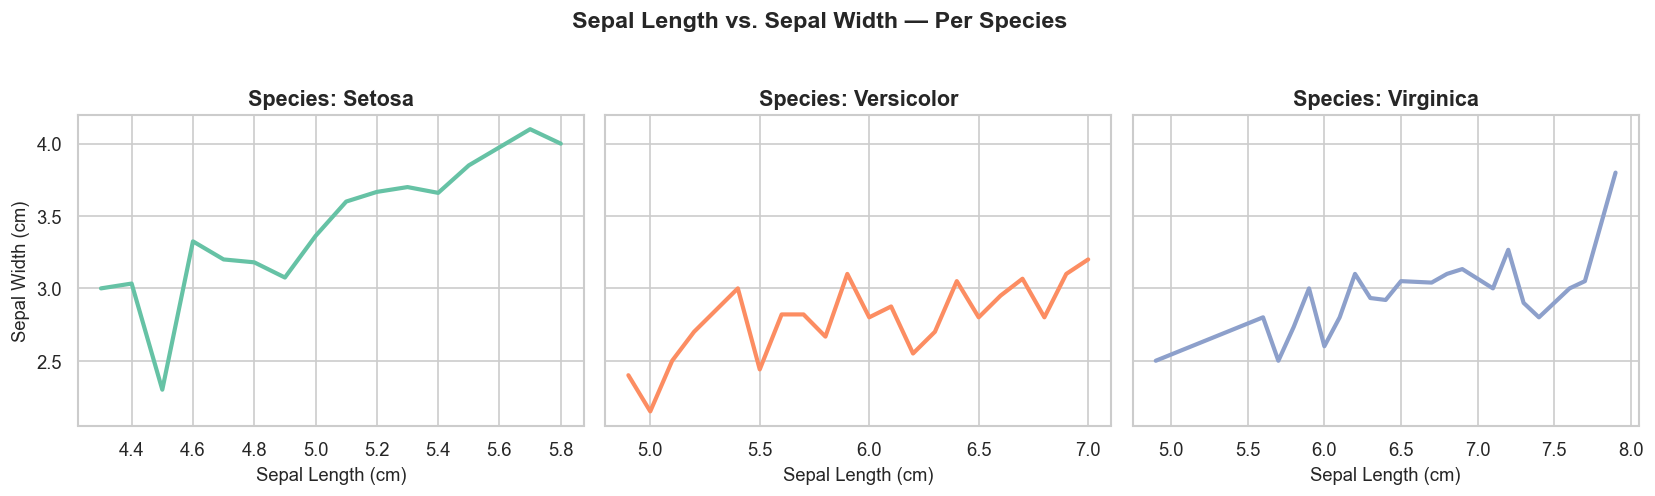

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
species_list = df['species'].unique()
colors = sns.color_palette("Set2", 3)

for ax, sp, col in zip(axes, species_list, colors):
    subset = df[df['species'] == sp].sort_values('sepal_length')
    sns.lineplot(x='sepal_length', y='sepal_width', data=subset,
                 ci=None, color=col, linewidth=2.5, ax=ax)
    ax.set_title(f"Species: {sp.capitalize()}", fontweight='bold')
    ax.set_xlabel("Sepal Length (cm)")
    ax.set_ylabel("Sepal Width (cm)" if ax == axes[0] else "")

plt.suptitle("Sepal Length vs. Sepal Width — Per Species", fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

When separated by species, each group shows a **positive correlation** — longer sepals correspond to wider sepals within each species. This is a classic example of **Simpson's Paradox**.

### 2. Scatter Plots

A **scatter plot** shows the relationship between two continuous variables. Each point represents one sample.

#### a. Sepal Length vs. Sepal Width

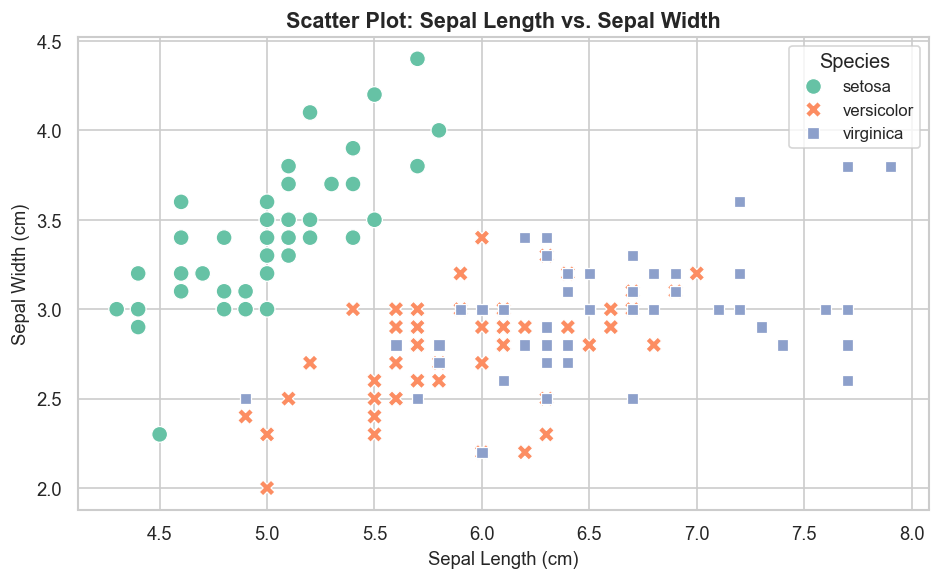

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x='sepal_length', y='sepal_width', data=df,
                hue='species', style='species', s=90, ax=ax)
ax.set_title("Scatter Plot: Sepal Length vs. Sepal Width", fontweight='bold')
ax.set_xlabel("Sepal Length (cm)")
ax.set_ylabel("Sepal Width (cm)")
ax.legend(title='Species')
plt.tight_layout()
plt.show()

**Setosa** (top-left cluster) is clearly separated from the other two species. Versicolor and virginica show some overlap — they are harder to separate using sepal dimensions alone.

#### b. Petal Length vs. Petal Width

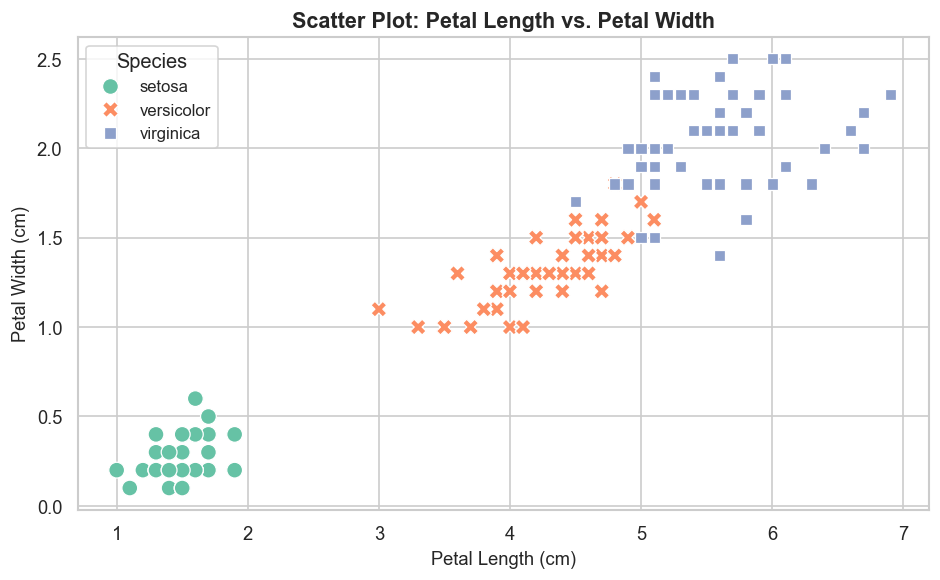

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x='petal_length', y='petal_width', data=df,
                hue='species', style='species', s=90, ax=ax)
ax.set_title("Scatter Plot: Petal Length vs. Petal Width", fontweight='bold')
ax.set_xlabel("Petal Length (cm)")
ax.set_ylabel("Petal Width (cm)")
ax.legend(title='Species')
plt.tight_layout()
plt.show()

This plot is the most discriminative scatter of the dataset:
- **Setosa**: bottom-left, clearly isolated
- **Versicolor**: middle cluster
- **Virginica**: top-right, with only slight overlap with versicolor

Petal dimensions are the **best two features** for visual and algorithmic classification.

### 3. Bar Plots

A **bar plot** aggregates a numerical variable by category (default: mean) and displays it as bars with error-bar confidence intervals.

#### a. Mean Sepal Length per Species

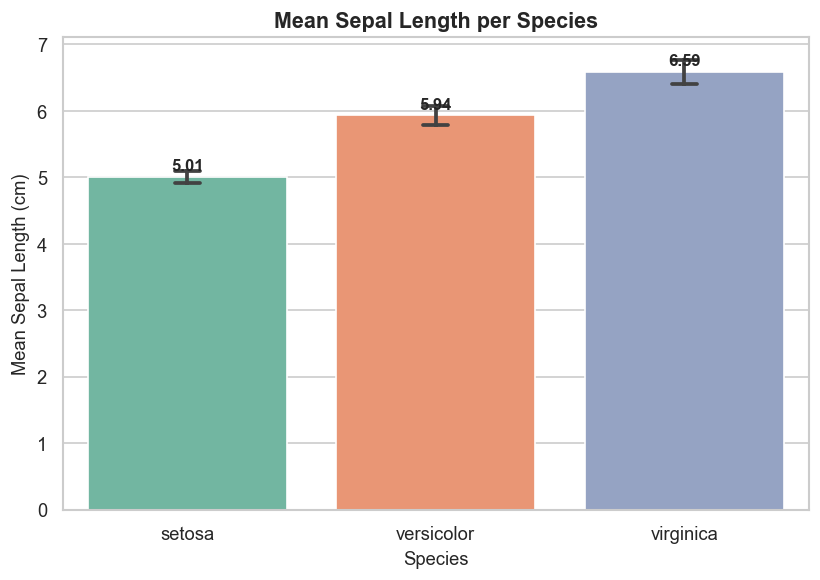

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x='species', y='sepal_length', data=df,
            palette='Set2', capsize=0.1, ax=ax)
ax.set_title("Mean Sepal Length per Species", fontweight='bold')
ax.set_xlabel("Species")
ax.set_ylabel("Mean Sepal Length (cm)")
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

The error bars (confidence intervals) show variability. Virginica has the longest sepal on average (≈6.59 cm), while setosa has the shortest (≈5.01 cm). The bars annotated with mean values help quick comparison.

#### b. All Feature Means per Species (Grouped Bar)


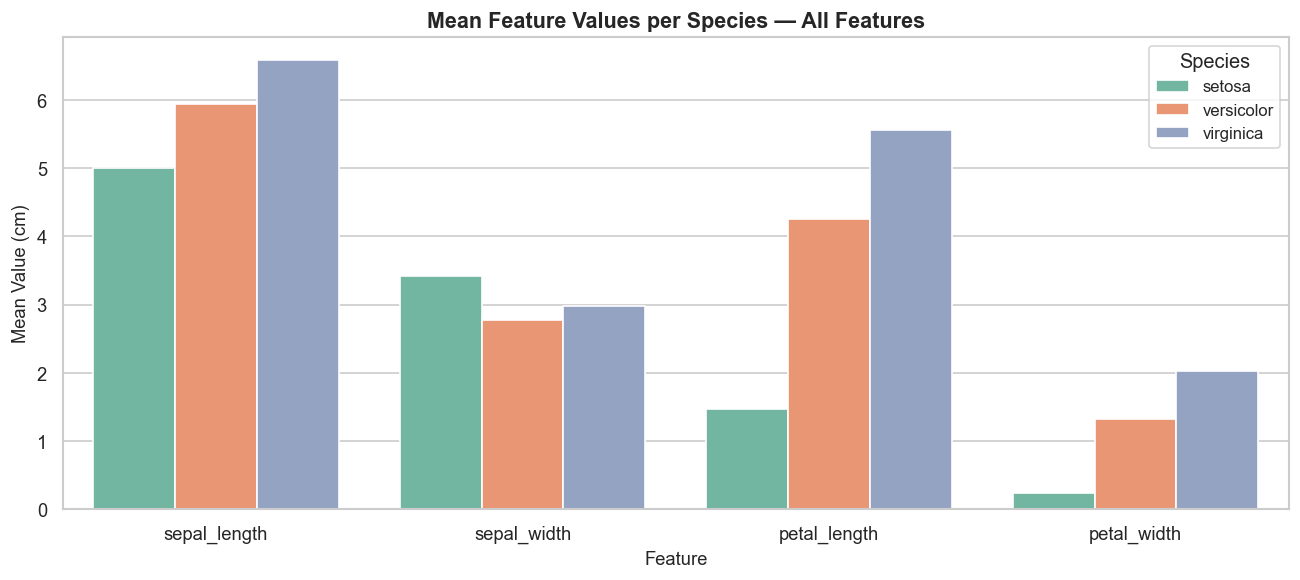

In [11]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
means = df.groupby('species')[features].mean().reset_index()
means_melted = means.melt(id_vars='species', var_name='Feature', value_name='Mean (cm)')

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x='Feature', y='Mean (cm)', hue='species', data=means_melted,
            palette='Set2', capsize=0.08, ax=ax)
ax.set_title("Mean Feature Values per Species — All Features", fontweight='bold')
ax.set_xlabel("Feature")
ax.set_ylabel("Mean Value (cm)")
ax.legend(title='Species')
plt.tight_layout()
plt.show()

Across all four features, **virginica consistently ranks highest**, and **setosa ranks lowest** for petal features while showing relatively wide sepals.

### 4. Box Plots

A **box plot** (box-and-whisker plot) compactly displays the distribution of a numerical variable:
- **Box** = Interquartile Range (Q1 to Q3)
- **Line inside box** = Median (Q2)
- **Whiskers** = 1.5 × IQR beyond Q1 and Q3
- **Dots** = Outliers

#### a. Sepal Width — Single Feature (No Species Split)

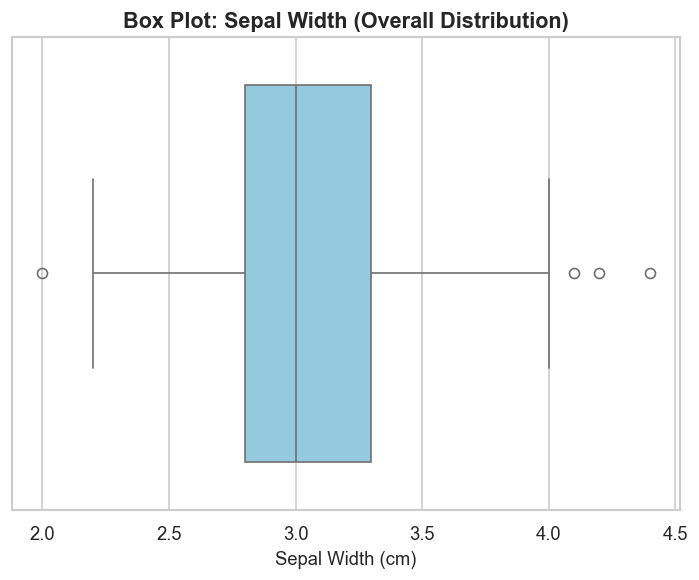

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(x='sepal_width', data=df, color='skyblue', ax=ax)
ax.set_title("Box Plot: Sepal Width (Overall Distribution)", fontweight='bold')
ax.set_xlabel("Sepal Width (cm)")
plt.tight_layout()
plt.show()

The overall sepal width is centred around 3 cm. A few outliers are visible on both ends, hinting at unusual specimens.

#### b. Individual Feature Box Plots — Four Panels


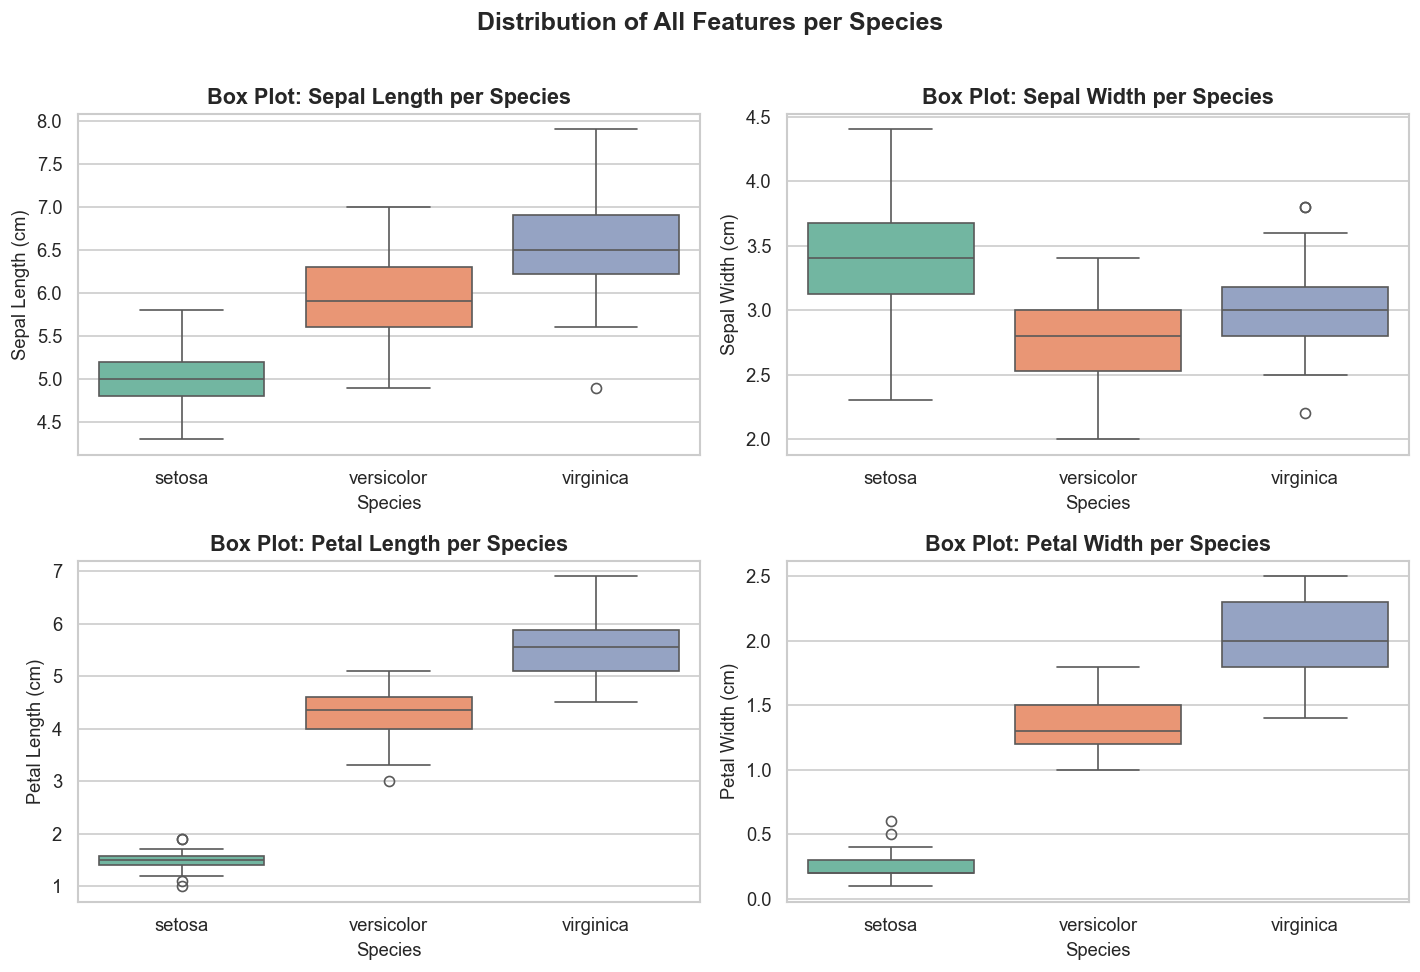

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
titles   = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']

for ax, feat, title in zip(axes.flat, features, titles):
    sns.boxplot(x='species', y=feat, data=df, palette='Set2', ax=ax)
    ax.set_title(f"Box Plot: {title} per Species", fontweight='bold')
    ax.set_xlabel("Species")
    ax.set_ylabel(f"{title} (cm)")

plt.suptitle("Distribution of All Features per Species", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The four-panel view confirms that **petal features** (bottom row) exhibit the most inter-species separation — setosa is completely isolated in petal_length and petal_width, making it the easiest species to classify.

### 5. Histograms

A **histogram** groups continuous values into bins and shows their frequency. It reveals the underlying distribution shape: normal, skewed, bimodal, etc.

#### Per-Feature Histograms — Four Panels

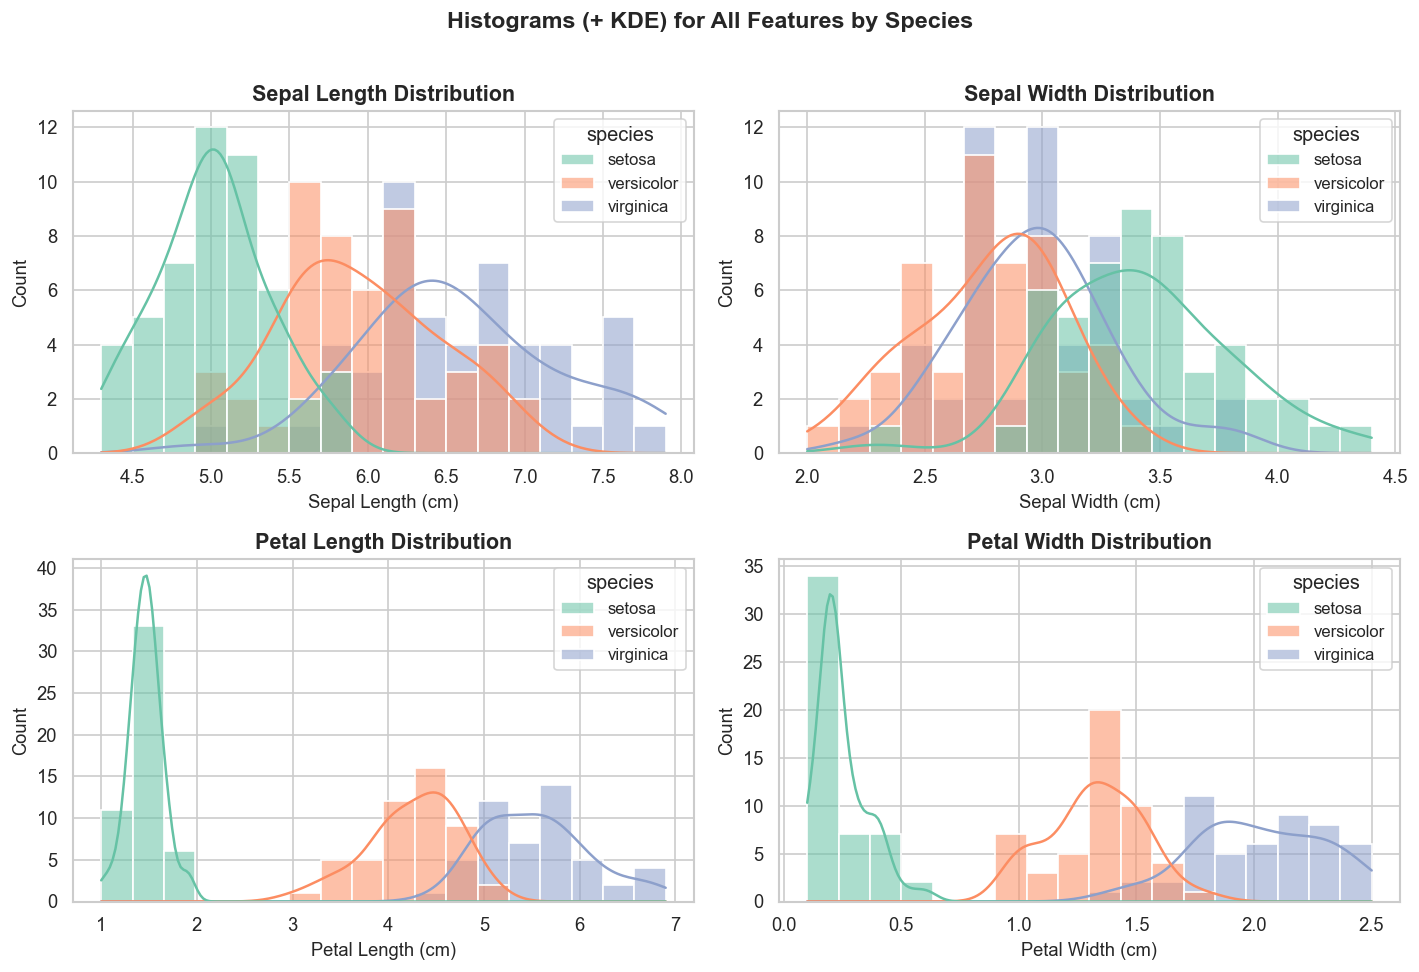

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
titles   = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']

for ax, feat, title in zip(axes.flat, features, titles):
    sns.histplot(x=feat, data=df, hue='species', bins=18,
                 kde=True, palette='Set2', alpha=0.55, ax=ax)
    ax.set_title(f"{title} Distribution", fontweight='bold')
    ax.set_xlabel(f"{title} (cm)")
    ax.set_ylabel("Count")

plt.suptitle("Histograms (+ KDE) for All Features by Species", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Petal features (bottom row) show clearly separated peaks per species. Sepal features overlap more, especially between versicolor and virginica.

### 6. KDE / Density Plot

A **KDE (Kernel Density Estimate) plot** is a smoothed, continuous version of a histogram. It estimates the probability density function of the data, making it easier to compare shapes.

#### Petal Width — Single KDE


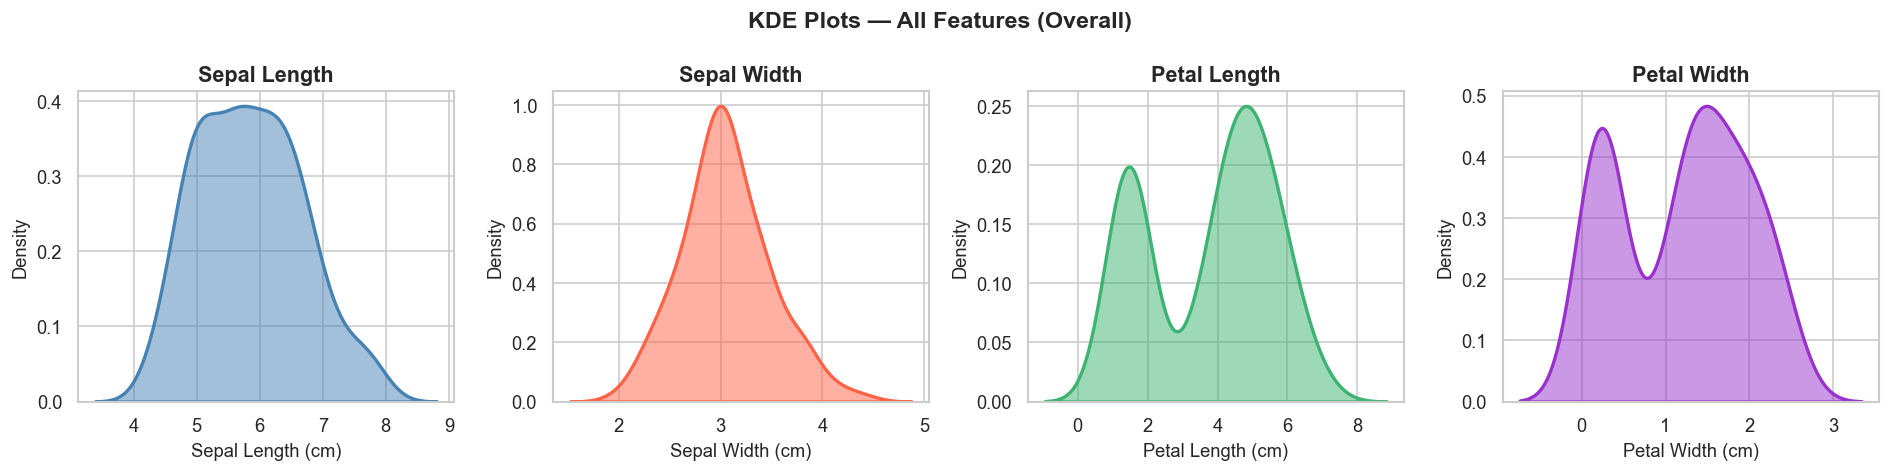

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
titles   = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']
colors   = ['steelblue', 'tomato', 'mediumseagreen', 'darkorchid']

for ax, feat, title, col in zip(axes, features, titles, colors):
    sns.kdeplot(x=feat, data=df, fill=True, color=col, alpha=0.5, linewidth=2, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(f"{title} (cm)")
    ax.set_ylabel("Density")

plt.suptitle("KDE Plots — All Features (Overall)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Sepal width** follows a roughly normal distribution. **Petal length** and **petal width** are strongly bimodal due to setosa's compact values being well-separated from the other two species.

### 7. Pair Plot

A **pair plot** displays pairwise scatter plots for every combination of numeric features. Diagonal plots show the distribution of each individual feature (as KDE).

This is one of the most powerful exploratory tools — it reveals relationships between all feature pairs simultaneously.


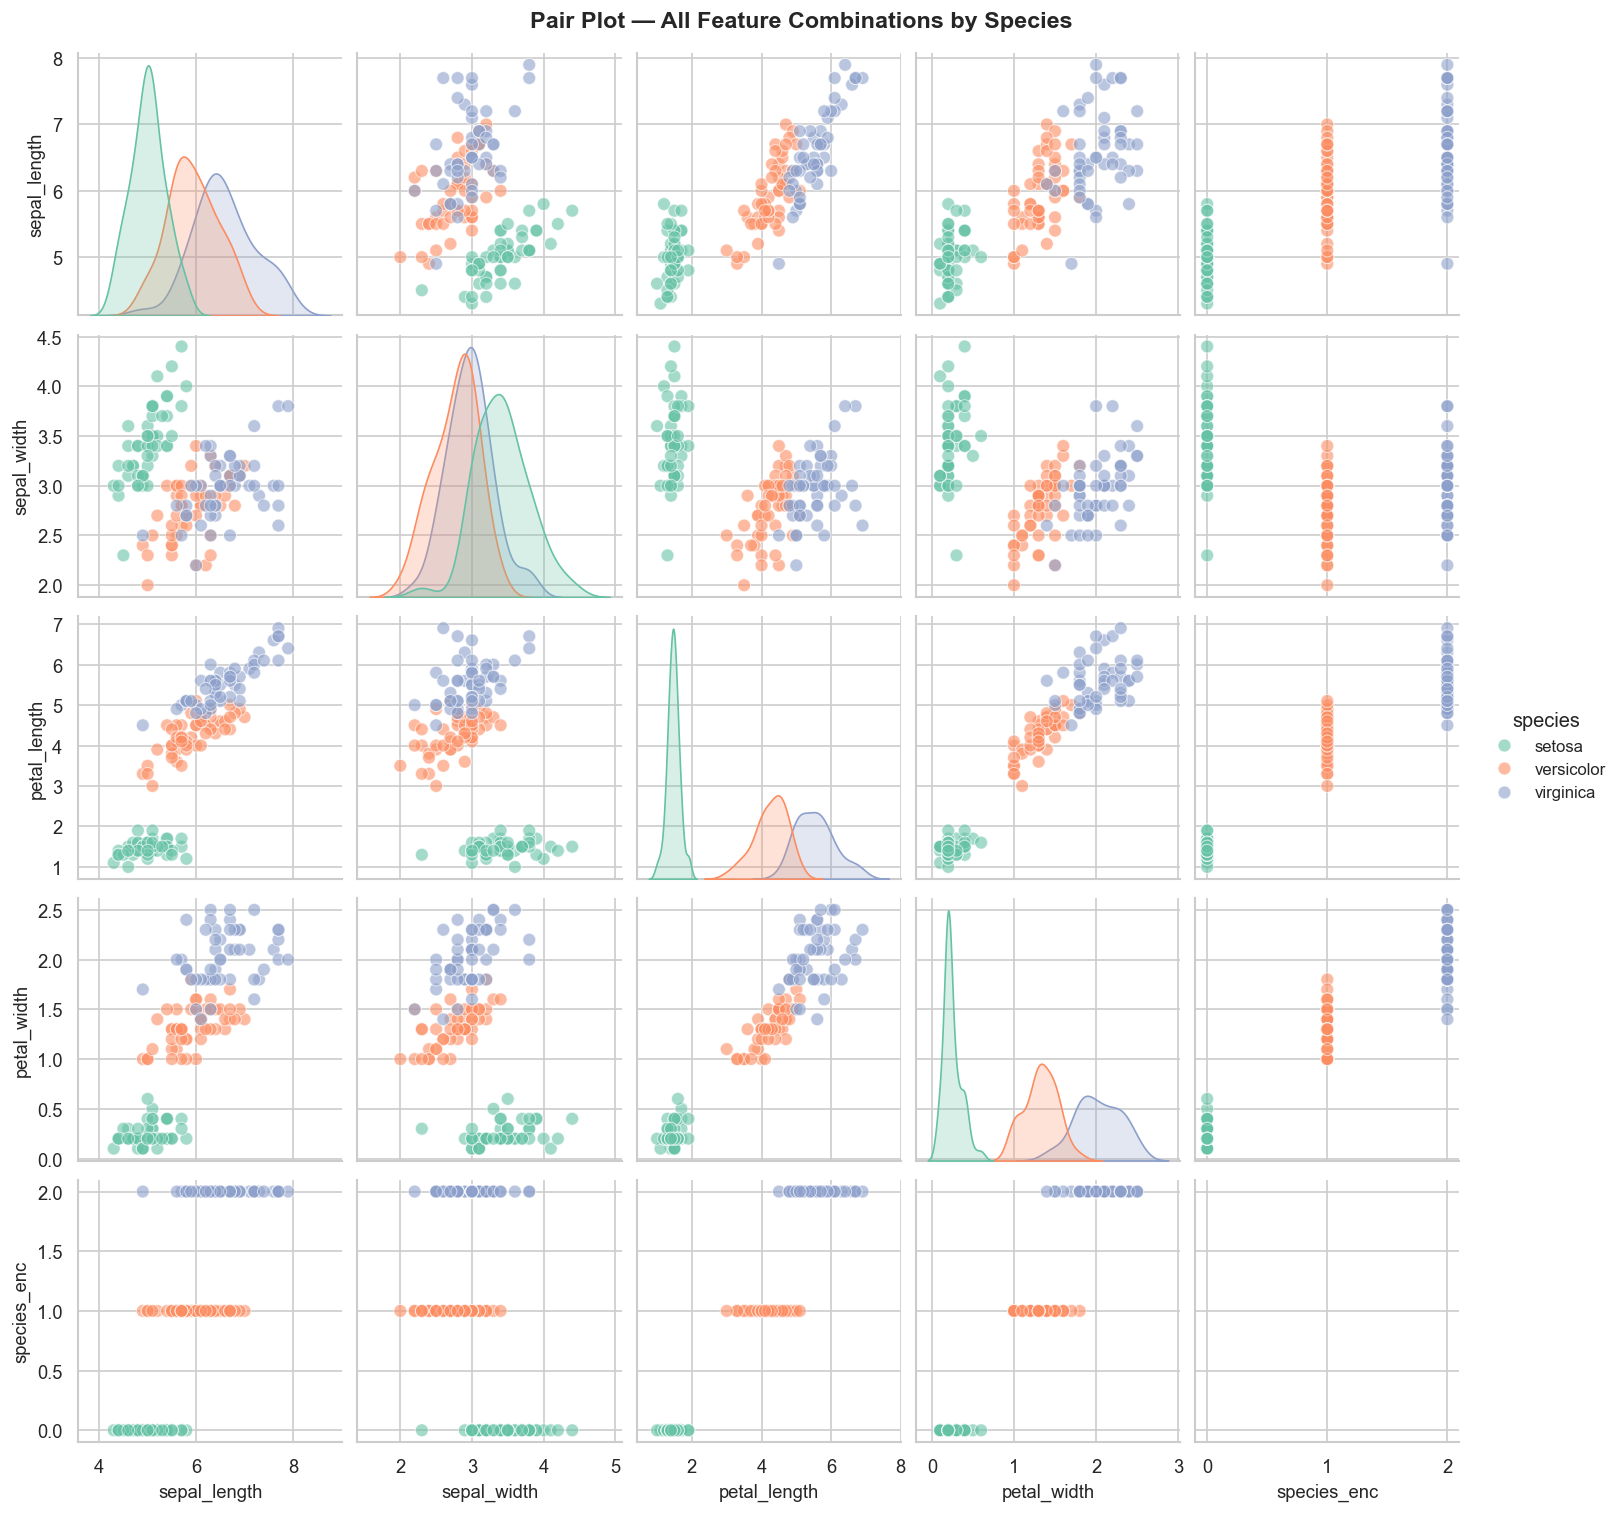

In [16]:
g = sns.pairplot(data=df, hue='species', palette='Set2',
                 diag_kind='kde', plot_kws={'alpha': 0.6, 's': 60})
g.fig.suptitle("Pair Plot — All Feature Combinations by Species",
               y=1.01, fontsize=14, fontweight='bold')
plt.show()

**Key takeaways from the pair plot:**
- The **petal_length vs petal_width** scatter (and its transpose) shows the cleanest species separation.
- **Setosa** is always isolated in petal-related axes.
- The diagonal KDE plots confirm petal features have the most distinct per-species peaks.
- Sepal features show more overlap, especially between versicolor and virginica.

> This pair plot is the **single most informative visualization** for understanding the Iris dataset.

### 8. Correlation Analysis & Heat Map

**Correlation** measures the linear relationship between two variables:
- **+1** → Perfect positive correlation (both increase together)
- **0** → No linear relationship
- **−1** → Perfect negative correlation (one increases as the other decreases)

#### a. Correlation Matrix

In [17]:
numeric_df = df.drop(columns=['species'])
corr_matrix = numeric_df.corr().round(2)
print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
              sepal_length  sepal_width  petal_length  petal_width  \
sepal_length          1.00        -0.11          0.87         0.82   
sepal_width          -0.11         1.00         -0.42        -0.36   
petal_length          0.87        -0.42          1.00         0.96   
petal_width           0.82        -0.36          0.96         1.00   
species_enc           0.78        -0.42          0.95         0.96   

              species_enc  
sepal_length         0.78  
sepal_width         -0.42  
petal_length         0.95  
petal_width          0.96  
species_enc          1.00  


#### b. Heat Map — Correlation Matrix

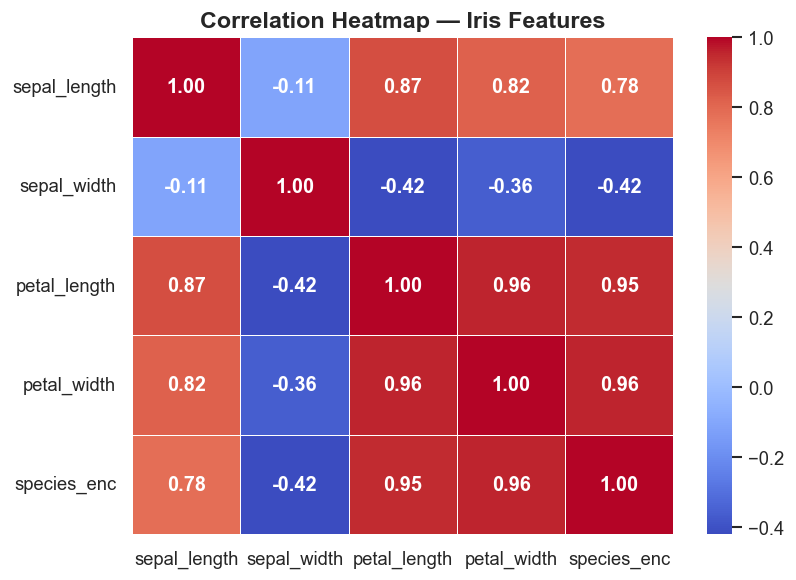

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 12, 'weight': 'bold'}, ax=ax)
ax.set_title("Correlation Heatmap — Iris Features", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

**Interpretation:**
| Pair | Correlation | Meaning |
|---|---|---|
| petal_length ↔ petal_width | **+0.96** | Very strong positive |
| sepal_length ↔ petal_length | **+0.87** | Strong positive |
| sepal_length ↔ petal_width | **+0.82** | Strong positive |
| sepal_width ↔ petal_length | **−0.43** | Moderate negative |
| sepal_width ↔ sepal_length | **−0.12** | Weak negative |

Petal length and petal width are almost perfectly correlated (r = 0.96). Sepal width is the least correlated with other features.

#### c. Per-Species Correlation Heatmaps

Correlations can differ per species. Let's compute and visualise the correlation matrix for each species individually.

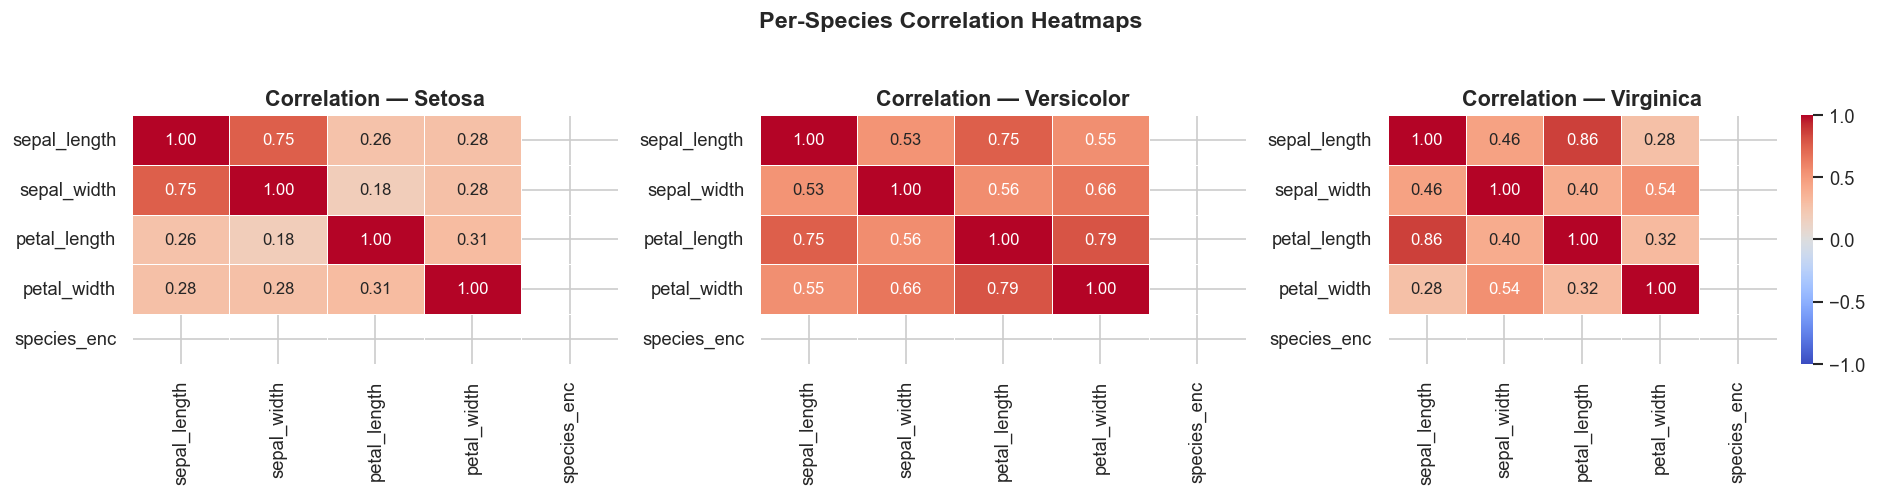

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
species_list = df['species'].unique()

for ax, sp in zip(axes, species_list):
    subset = df[df['species'] == sp].drop(columns='species')
    corr = subset.corr().round(2)
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                linewidths=0.5, linecolor='white',
                annot_kws={'size': 10}, ax=ax,
                vmin=-1, vmax=1, cbar=(sp == species_list[-1]))
    ax.set_title(f"Correlation — {sp.capitalize()}", fontweight='bold')

plt.suptitle("Per-Species Correlation Heatmaps", fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

Correlation structures differ markedly between species:
- **Setosa** shows very different (sometimes negative) petal correlations compared to the overall dataset.
- **Virginica** has the strongest within-species petal correlation.
- This highlights why species must be considered when interpreting any single feature relationship.

### Final Summary — Visualization Reference Table

Below is a comprehensive reference table summarising every plot type used in this notebook, its Seaborn function, best use-case, and key finding for the Iris dataset.

In [20]:
summary_data = {
    'Plot Type':       ['Line Plot', 'Scatter Plot', 'Bar Plot','Box Plot', 
                        'Histogram','KDE Plot', 'Pair Plot', 'Heatmap'],
    'Seaborn Function':['sns.lineplot()', 'sns.scatterplot()', 'sns.barplot()','sns.boxplot()',
                        'sns.histplot()', 'sns.kdeplot()', 'sns.pairplot()', 'sns.heatmap()'],
    'Variable Type':   ['Num × Num', 'Num × Num', 'Cat × Num', 'Cat × Num',
                        'Numerical','Numerical', 'All Pairs', 'Matrix'],
    'Key Iris Finding':['Negative overall trend; positive per-species',
                        'Petal dims best separate all 3 species',
                        'Virginica highest sepal, setosa lowest petal',
                        'Setosa has widest sepals; petal IQRs non-overlapping',
                        'Petal width bimodal — setosa vs rest',
                        'Petal features strongly bimodal; sepal width normal',
                        'Petal_length × petal_width = best pair for separation',
                        'petal_length ↔ petal_width = 0.96 (strongest corr)']
}

summary_df = pd.DataFrame(summary_data)
summary_df.index = range(1, len(summary_df)+1)
summary_df

,Plot Type,Seaborn Function,Variable Type,Key Iris Finding
1,Line Plot,sns.lineplot(),Num × Num,Negative overall trend; positive per-species
2,Scatter Plot,sns.scatterplot(),Num × Num,Petal dims best separate all 3 species
3,Bar Plot,sns.barplot(),Cat × Num,"Virginica highest sepal, setosa lowest petal"
4,Box Plot,sns.boxplot(),Cat × Num,Setosa has widest sepals; petal IQRs non-overl...
5,Histogram,sns.histplot(),Numerical,Petal width bimodal — setosa vs rest
6,KDE Plot,sns.kdeplot(),Numerical,Petal features strongly bimodal; sepal width n...
7,Pair Plot,sns.pairplot(),All Pairs,Petal_length × petal_width = best pair for sep...
8,Heatmap,sns.heatmap(),Matrix,petal_length ↔ petal_width = 0.96 (strongest c...
